In [1]:
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
from qiskit.converters import circuit_to_dag, dag_to_circuit
from QiskitTranspiler.transpiler.transpile import transpile

31


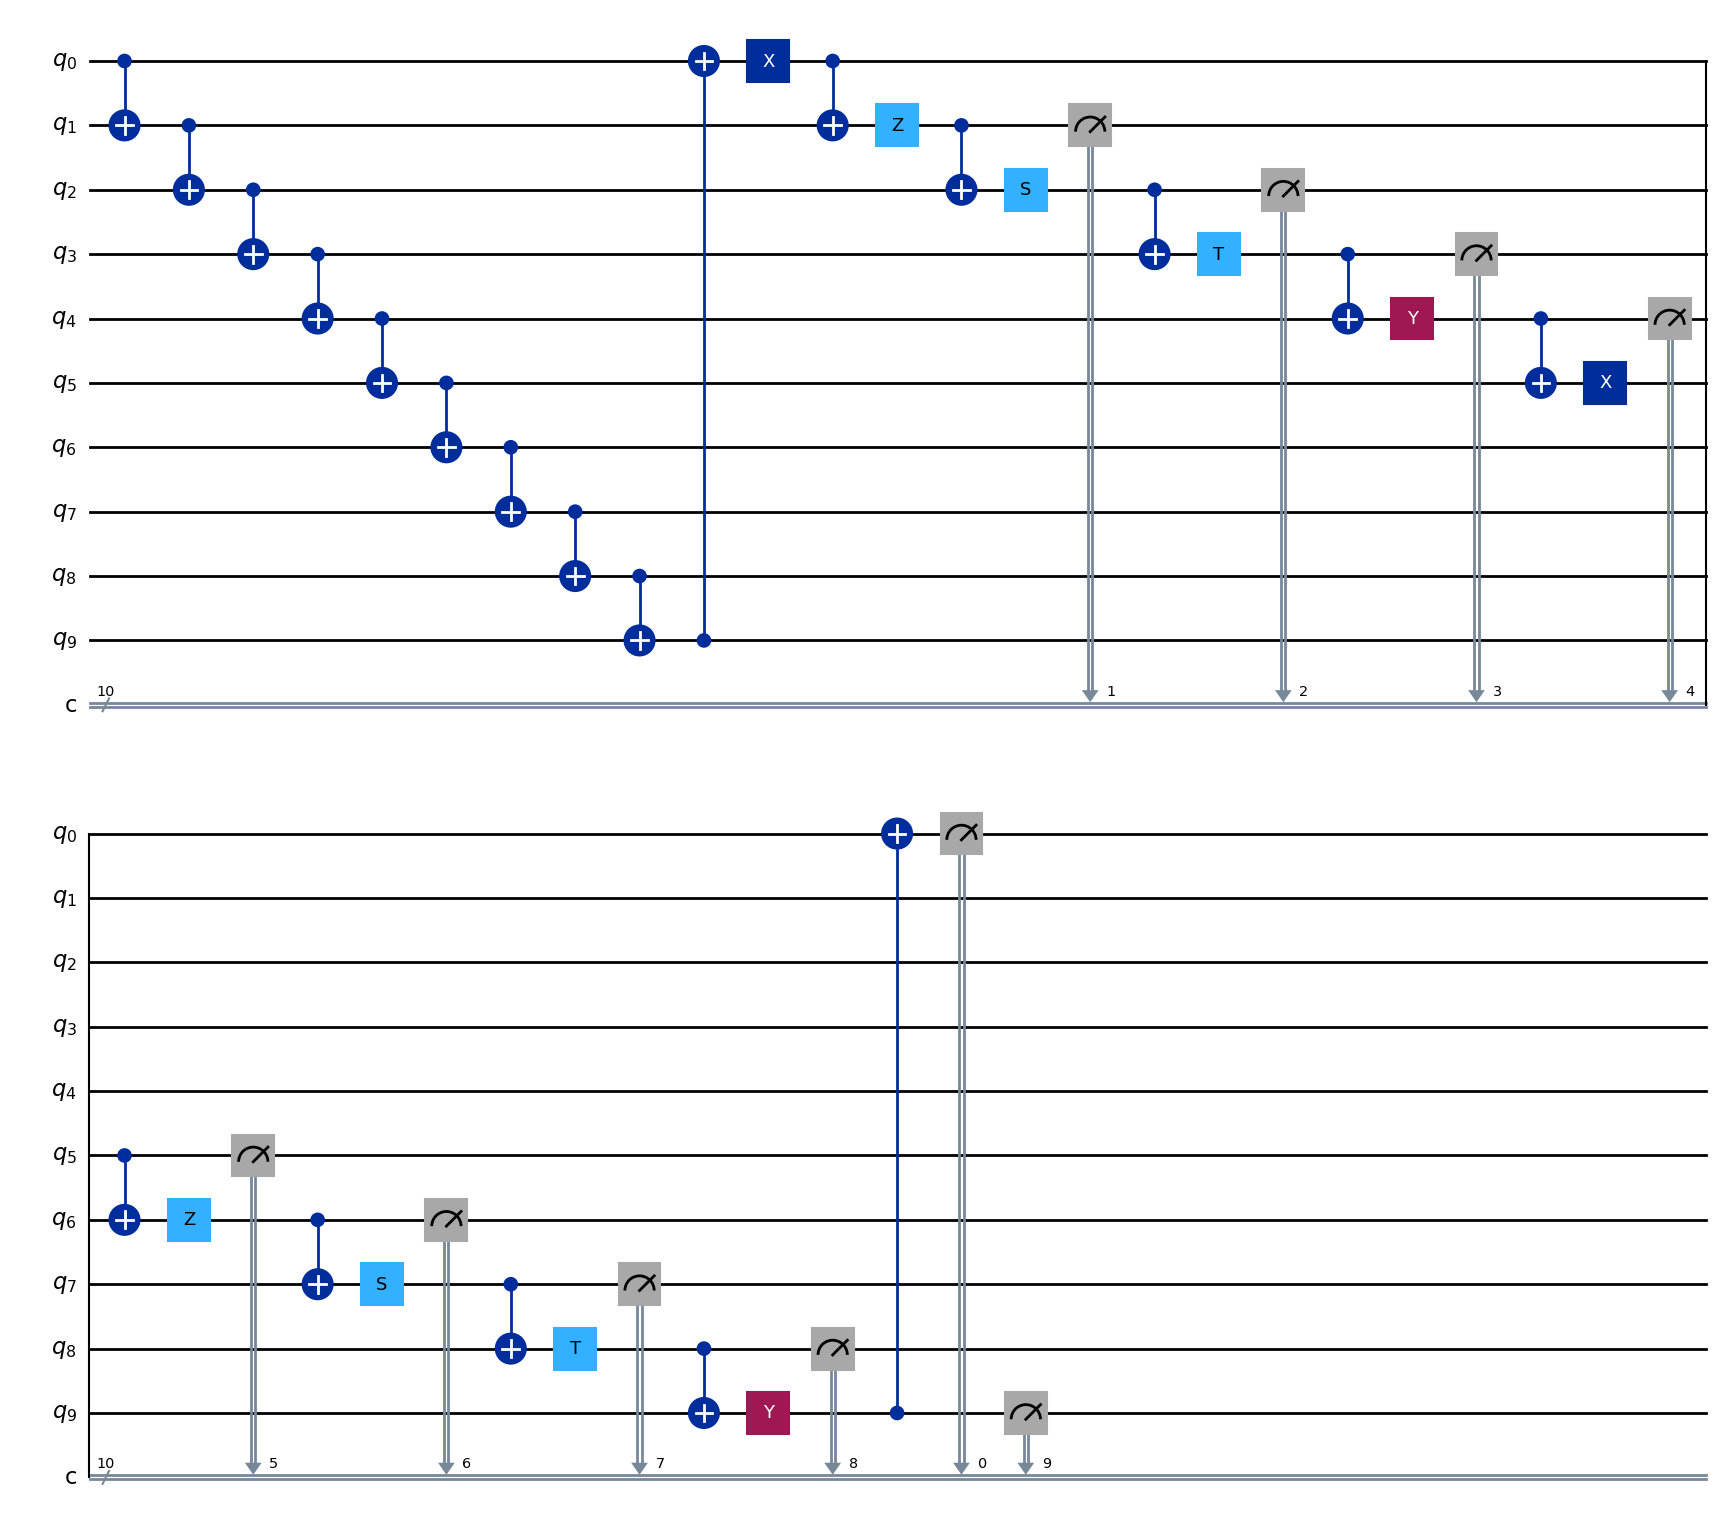

In [2]:
qc = QuantumCircuit(10, 10)
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(2, 3)
qc.cx(3, 4)
qc.cx(4, 5)
qc.cx(5, 6)
qc.cx(6, 7)
qc.cx(7, 8)
qc.cx(8, 9)
qc.cx(9, 0)

qc.x(0)
qc.cx(0, 1)
qc.z(1)
qc.cx(1, 2)
qc.s(2)

qc.cx(2, 3)
qc.t(3)
qc.cx(3, 4)
qc.y(4)
qc.cx(4, 5)
qc.x(5)
qc.cx(5, 6)
qc.z(6)
qc.cx(6, 7)
qc.s(7)
qc.cx(7, 8)
qc.t(8)
qc.cx(8, 9)
qc.y(9)
qc.cx(9, 0)
qc.measure(range(10), range(10))
print(qc.depth())
qc.draw("mpl")

# Simulated Hardware
## Run the circuit 50 times with the custom transpiler and then with the Qiskit transpiler

In [4]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

#Testing first with a simulator, then with a real backend
backend = FakeFez()

from QiskitTranspiler.transpiler.transpile import transpile

transpiled_circuit = transpile(qc, backend)

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


In [6]:
sampler = Sampler(mode=backend)

experiment_errors = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "0111101111":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)

print("Average error over 50 runs (Qiskit transpiler):", sum(experiment_errors) / len(experiment_errors))
print("Errors for each run:", experiment_errors)

Average error over 50 runs (Qiskit transpiler): 0.3289453125
Errors for each run: [0.3134765625, 0.333984375, 0.3291015625, 0.330078125, 0.3115234375, 0.3359375, 0.3349609375, 0.326171875, 0.353515625, 0.328125, 0.34765625, 0.32421875, 0.353515625, 0.3134765625, 0.3046875, 0.3583984375, 0.3173828125, 0.3486328125, 0.3271484375, 0.341796875, 0.3359375, 0.3173828125, 0.33984375, 0.3134765625, 0.291015625, 0.3232421875, 0.3193359375, 0.302734375, 0.3251953125, 0.35546875, 0.330078125, 0.3388671875, 0.3291015625, 0.337890625, 0.31640625, 0.3486328125, 0.3291015625, 0.3203125, 0.3310546875, 0.3134765625, 0.3388671875, 0.3515625, 0.2978515625, 0.32421875, 0.306640625, 0.349609375, 0.3330078125, 0.330078125, 0.3359375, 0.3271484375]


In [1]:
import numpy as np
errors = [0.3134765625, 0.333984375, 0.3291015625, 0.330078125, 0.3115234375, 0.3359375, 0.3349609375, 0.326171875, 0.353515625, 0.328125, 0.34765625, 0.32421875, 0.353515625, 0.3134765625, 0.3046875, 0.3583984375, 0.3173828125, 0.3486328125, 0.3271484375, 0.341796875, 0.3359375, 0.3173828125, 0.33984375, 0.3134765625, 0.291015625, 0.3232421875, 0.3193359375, 0.302734375, 0.3251953125, 0.35546875, 0.330078125, 0.3388671875, 0.3291015625, 0.337890625, 0.31640625, 0.3486328125, 0.3291015625, 0.3203125, 0.3310546875, 0.3134765625, 0.3388671875, 0.3515625, 0.2978515625, 0.32421875, 0.306640625, 0.349609375, 0.3330078125, 0.330078125, 0.3359375, 0.3271484375]
mean_error = np.mean(errors)
print("Mean error over 50 runs:", mean_error)
std = np.std(errors)
print("Standard deviation of errors over 50 runs:", std)
ci95 = 1.96 * std / np.sqrt(len(errors))
print(f"{mean_error:.4f} ± {ci95:.4f} (95% CI)")

Mean error over 50 runs: 0.3289453125
Standard deviation of errors over 50 runs: 0.015344603225386158
0.3289 ± 0.0043 (95% CI)


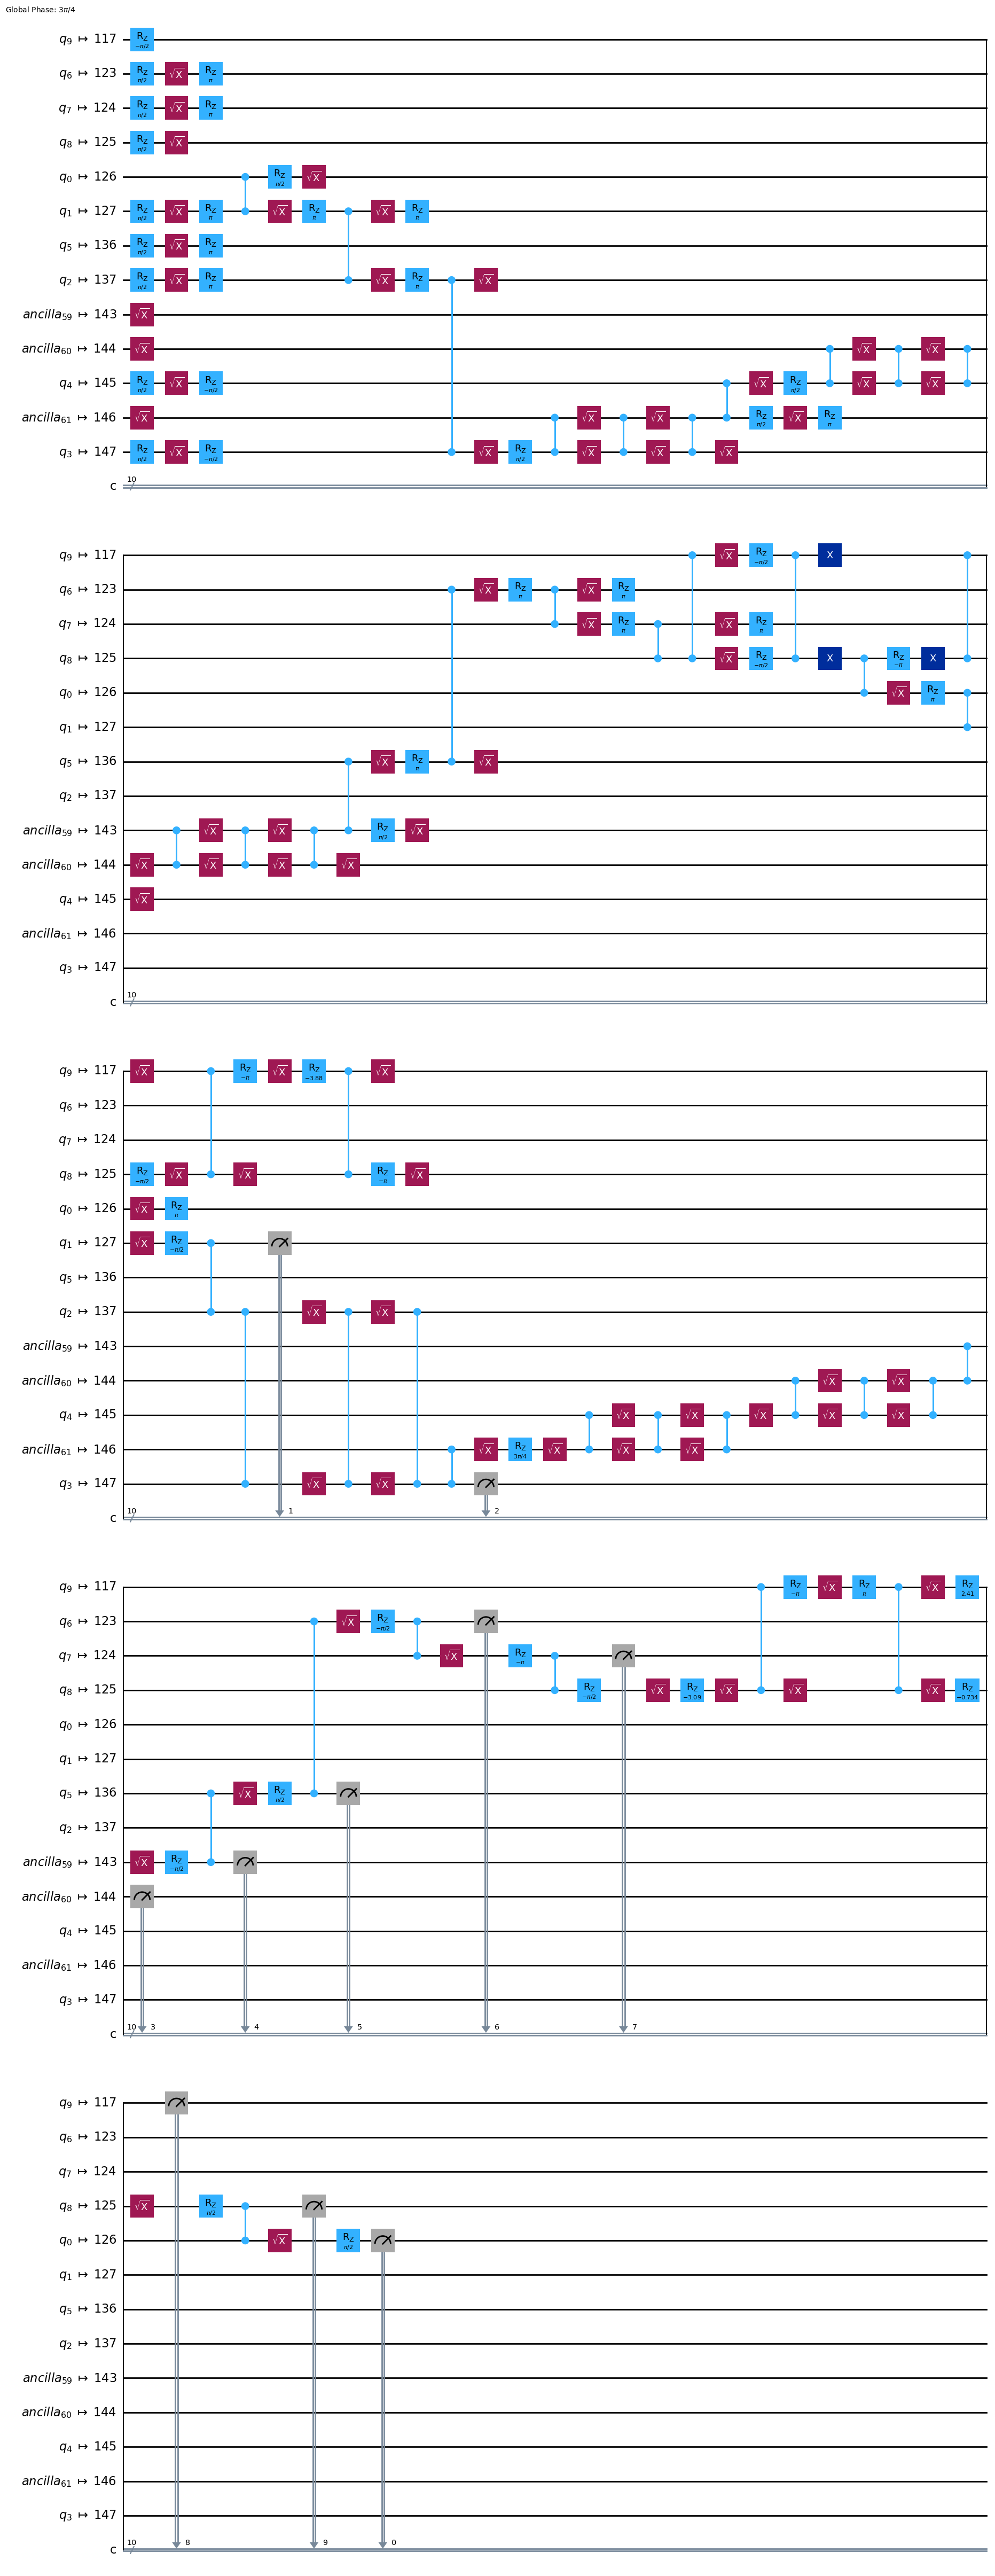

In [7]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit import transpile

#Testing first with a simulator, then with a real backend
backend = FakeFez()

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")

In [8]:
sampler = Sampler(mode=backend)

experiment_errors = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "0111101111":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)

print("Average error over 50 runs (Qiskit transpiler):", sum(experiment_errors) / len(experiment_errors))
print("Errors for each run:", experiment_errors)

Average error over 50 runs (Qiskit transpiler): 0.1963671875
Errors for each run: [0.2001953125, 0.2099609375, 0.1982421875, 0.2080078125, 0.2138671875, 0.205078125, 0.1767578125, 0.1826171875, 0.185546875, 0.1748046875, 0.1875, 0.1796875, 0.1806640625, 0.212890625, 0.1953125, 0.2265625, 0.1728515625, 0.2021484375, 0.1953125, 0.21875, 0.1865234375, 0.169921875, 0.1845703125, 0.197265625, 0.1962890625, 0.212890625, 0.201171875, 0.171875, 0.2158203125, 0.19140625, 0.1806640625, 0.2099609375, 0.197265625, 0.18359375, 0.208984375, 0.193359375, 0.2138671875, 0.208984375, 0.21484375, 0.1689453125, 0.1884765625, 0.2001953125, 0.1962890625, 0.208984375, 0.1943359375, 0.1845703125, 0.19140625, 0.20703125, 0.2197265625, 0.1923828125]


In [2]:
import numpy as np
errors = [0.2001953125, 0.2099609375, 0.1982421875, 0.2080078125, 0.2138671875, 0.205078125, 0.1767578125, 0.1826171875, 0.185546875, 0.1748046875, 0.1875, 0.1796875, 0.1806640625, 0.212890625, 0.1953125, 0.2265625, 0.1728515625, 0.2021484375, 0.1953125, 0.21875, 0.1865234375, 0.169921875, 0.1845703125, 0.197265625, 0.1962890625, 0.212890625, 0.201171875, 0.171875, 0.2158203125, 0.19140625, 0.1806640625, 0.2099609375, 0.197265625, 0.18359375, 0.208984375, 0.193359375, 0.2138671875, 0.208984375, 0.21484375, 0.1689453125, 0.1884765625, 0.2001953125, 0.1962890625, 0.208984375, 0.1943359375, 0.1845703125, 0.19140625, 0.20703125, 0.2197265625, 0.1923828125]
mean_error = np.mean(errors)
print("Mean error over 50 runs:", mean_error)
std = np.std(errors)
print("Standard deviation of errors over 50 runs:", std)
ci95 = 1.96 * std / np.sqrt(len(errors))
print(f"{mean_error:.4f} ± {ci95:.4f} (95% CI)")

Mean error over 50 runs: 0.1963671875
Standard deviation of errors over 50 runs: 0.014415914938554021
0.1964 ± 0.0040 (95% CI)


# REAL QUANTUM HARDWARE
## We run each circuit 10 times with the custom transpiler and 10 times with the Qiskit transpiler

In [9]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

# See all available backends
for b in service.backends():
    print(b.name, b.num_qubits, b.status().pending_jobs)

ibm_fez 156 0
ibm_marrakesh 156 0
ibm_kingston 156 0


In [10]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from QiskitTranspiler.transpiler.transpile import transpile

transpiled_circuit = transpile(qc, backend)
# transpiled_circuit.draw("mpl")

Running on: ibm_fez (156 qubits)
[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


In [11]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7eche3klj2c73f2k2fg
Job ID: d7echeb0g7hs73dsrtgg
Job ID: d7echebklj2c73f2k2h0
Job ID: d7echej0g7hs73dsrtig
Job ID: d7echep5a5qc73dqprqg
Job ID: d7echf30g7hs73dsrtj0
Job ID: d7echf95a5qc73dqprs0
Job ID: d7echfm5nvhs73a6jn50
Job ID: d7echfp5a5qc73dqprtg
Job ID: d7echg65nvhs73a6jn60


In [12]:
job_ids = [
    "d7eche3klj2c73f2k2fg",
    "d7echeb0g7hs73dsrtgg",
    "d7echebklj2c73f2k2h0",
    "d7echej0g7hs73dsrtig",
    "d7echep5a5qc73dqprqg",
    "d7echf30g7hs73dsrtj0",
    "d7echf95a5qc73dqprs0",
    "d7echfm5nvhs73a6jn50",
    "d7echfp5a5qc73dqprtg",
    "d7echg65nvhs73a6jn60",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "0111101111":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7eche3klj2c73f2k2fg: error = 0.6123
Job d7echeb0g7hs73dsrtgg: error = 0.6094
Job d7echebklj2c73f2k2h0: error = 0.6357
Job d7echej0g7hs73dsrtig: error = 0.6162
Job d7echep5a5qc73dqprqg: error = 0.6465
Job d7echf30g7hs73dsrtj0: error = 0.6182
Job d7echf95a5qc73dqprs0: error = 0.6436
Job d7echfm5nvhs73a6jn50: error = 0.6250
Job d7echfp5a5qc73dqprtg: error = 0.5918
Job d7echg65nvhs73a6jn60: error = 0.6201

Average error over runs: 0.621875


Running on: ibm_fez (156 qubits)


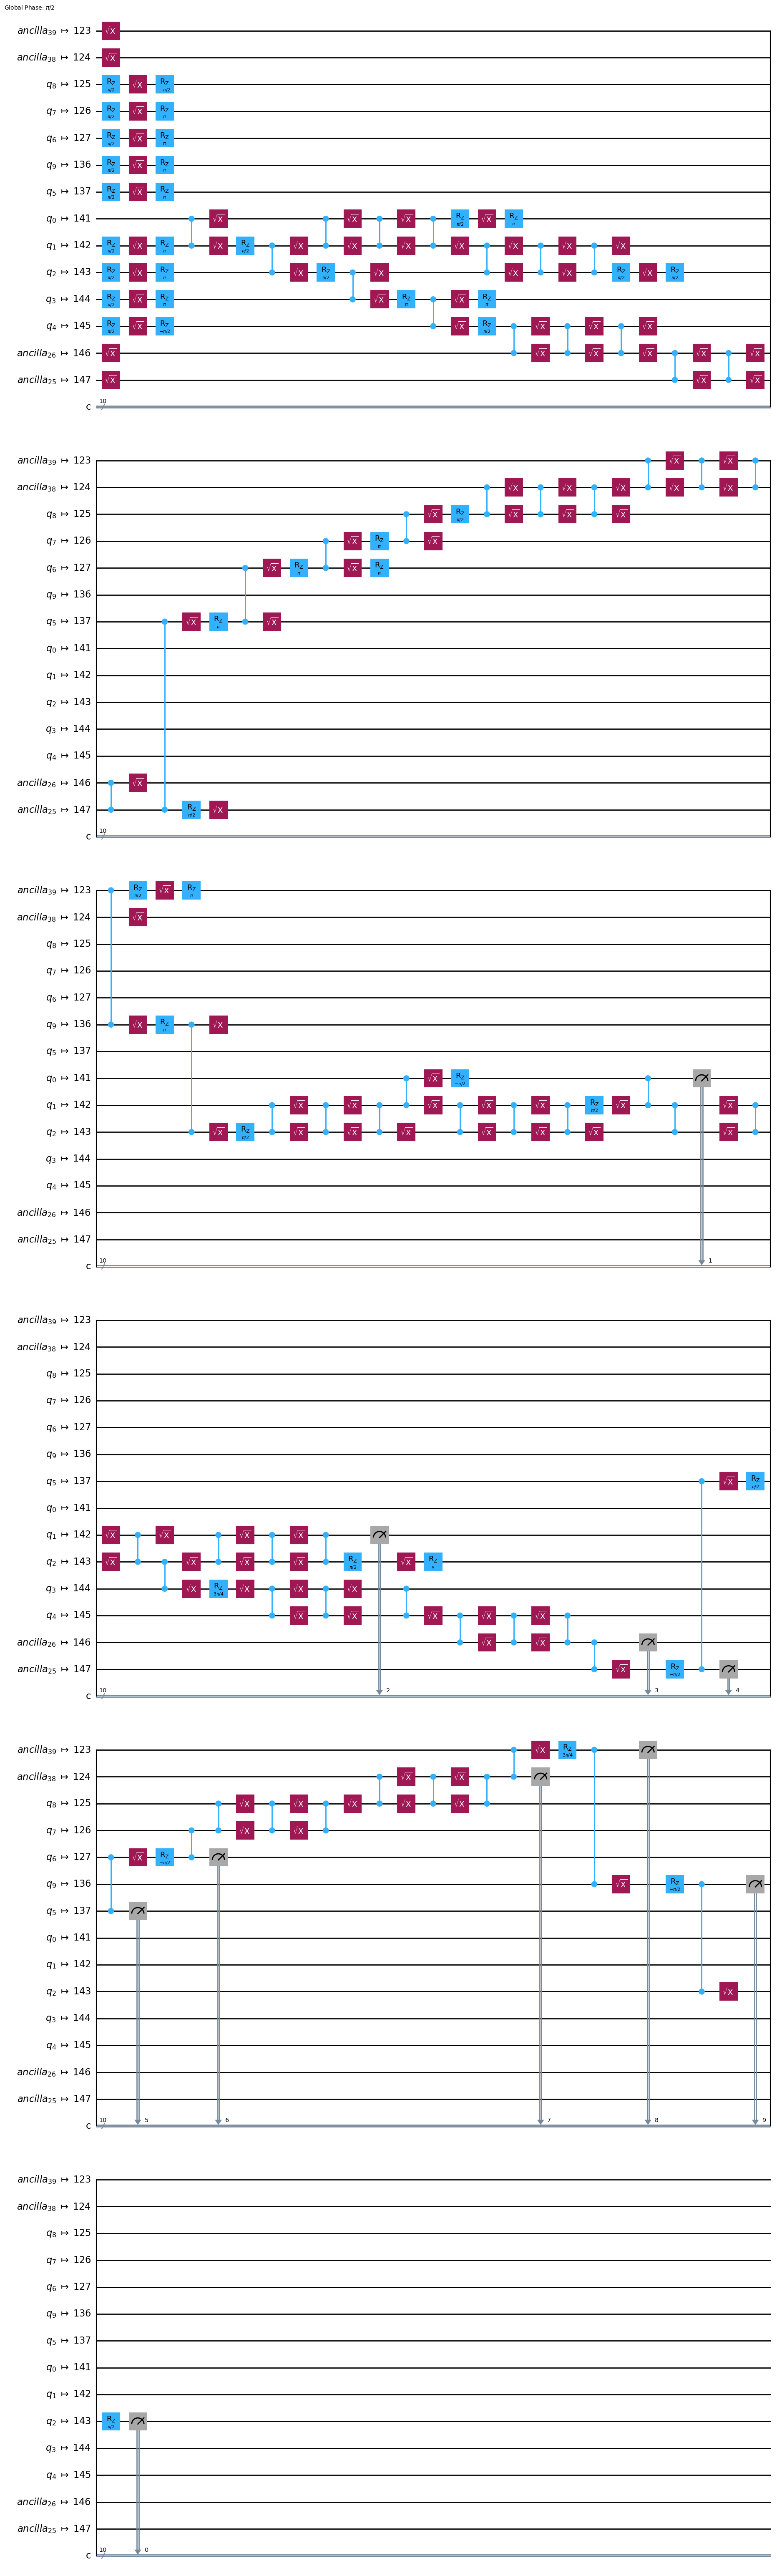

In [13]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from qiskit import transpile

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")
# qc.draw("mpl")

In [14]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7eci1h5a5qc73dqpse0
Job ID: d7eci1rklj2c73f2k350
Job ID: d7eci215a5qc73dqpsf0
Job ID: d7eci2bklj2c73f2k36g
Job ID: d7eci2j0g7hs73dsru90
Job ID: d7eci2rklj2c73f2k37g
Job ID: d7eci33klj2c73f2k380
Job ID: d7eci315a5qc73dqpshg
Job ID: d7eci395a5qc73dqpsig
Job ID: d7eci3jklj2c73f2k390


In [15]:
job_ids = [
    "d7eci1h5a5qc73dqpse0",
    "d7eci1rklj2c73f2k350",
    "d7eci215a5qc73dqpsf0",
    "d7eci2bklj2c73f2k36g",
    "d7eci2j0g7hs73dsru90",
    "d7eci2rklj2c73f2k37g",
    "d7eci33klj2c73f2k380",
    "d7eci315a5qc73dqpshg",
    "d7eci395a5qc73dqpsig",
    "d7eci3jklj2c73f2k390",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "0111101111":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7eci1h5a5qc73dqpse0: error = 0.4141
Job d7eci1rklj2c73f2k350: error = 0.4219
Job d7eci215a5qc73dqpsf0: error = 0.4375
Job d7eci2bklj2c73f2k36g: error = 0.4160
Job d7eci2j0g7hs73dsru90: error = 0.4150
Job d7eci2rklj2c73f2k37g: error = 0.4014
Job d7eci33klj2c73f2k380: error = 0.4199
Job d7eci315a5qc73dqpshg: error = 0.3965
Job d7eci395a5qc73dqpsig: error = 0.4219
Job d7eci3jklj2c73f2k390: error = 0.4092

Average error over runs: 0.41533203125


In [3]:
import time
from QiskitTranspiler.transpiler.transpile import transpile
from qiskit_ibm_runtime.fake_provider import FakeFez

backend = FakeFez()

start = time.perf_counter()
transpiled_circuit = transpile(qc, backend)
elapsed = time.perf_counter() - start

print("Original circuit:")
print(f"No. of Gates: {qc.size()}")
print(f"Depth: {qc.depth()}\n")

print("My transpiler:")
print(f"No. of Gates: {transpiled_circuit.size()}")
print(f"Depth: {transpiled_circuit.depth()}")
print(f"Transpilation time: {elapsed:.4f} seconds")

from qiskit import transpile

start = time.perf_counter()
transpiled_circuit = transpile(qc, backend)
elapsed = time.perf_counter() - start

print("\nQiskit transpiler:")
print(f"No. of Gates: {transpiled_circuit.size()}")
print(f"Depth: {transpiled_circuit.depth()}")
print(f"Transpilation time: {elapsed:.4f} seconds")

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'
Original circuit:
No. of Gates: 40
Depth: 31

My transpiler:
No. of Gates: 870
Depth: 502
Transpilation time: 2.1180 seconds

Qiskit transpiler:
No. of Gates: 245
Depth: 136
Transpilation time: 0.0595 seconds
